# DT and Ensemble Methods



## 1. Setup and Data Preparation

First, let's import the necessary libraries and load a dataset. We will use the **Breast Cancer Wisconsin (Diagnostic) dataset**, a classic dataset for binary classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost
import xgboost as xgb

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100 # Higher resolution for plots

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

print(f"Dataset shape: {X.shape}")
print(f"Target classes: {cancer.target_names}")
print(f"Number of features: {len(cancer.feature_names)}")

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']
Number of features: 30

Training set size: 455 samples
Testing set size: 114 samples


## 2. Decision Trees for Classification

Decision Trees are fundamental building blocks in machine learning. They make decisions by asking a series of questions about the data. Let's see how to use `DecisionTreeClassifier`.

### 2.1 Basic Decision Tree

We'll start with a basic Decision Tree and then explore its parameters.

In [5]:
# Initialize a basic Decision Tree Classifier
dt_basic = DecisionTreeClassifier(random_state=42)

# Train the model
dt_basic.fit(X_train, y_train)

# Make predictions on the test set
y_predict = dt_basic.predict(X_test)

# Evaluate the model
dt_basic_score = accuracy_score(y_test, y_predict)

print(f"\nClassification Report: {classification_report(y_test, y_predict, target_names=cancer.target_names)}")



Classification Report:               precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



### 2.2 Exploring Key Parameters of Decision Trees

Decision Trees can easily overfit the training data if not constrained. Here are some important parameters to control their complexity:

- `max_depth`: The maximum depth of the tree. A smaller value prevents the tree from becoming too deep and complex.
- `min_samples_split`: The minimum number of samples required to split an internal node. Higher values prevent splitting on small groups.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. Similar to `min_samples_split`, it controls the size of leaf nodes.
- `criterion`: The function to measure the quality of a split. Common choices are `gini` (Gini impurity) and `entropy` (information gain).

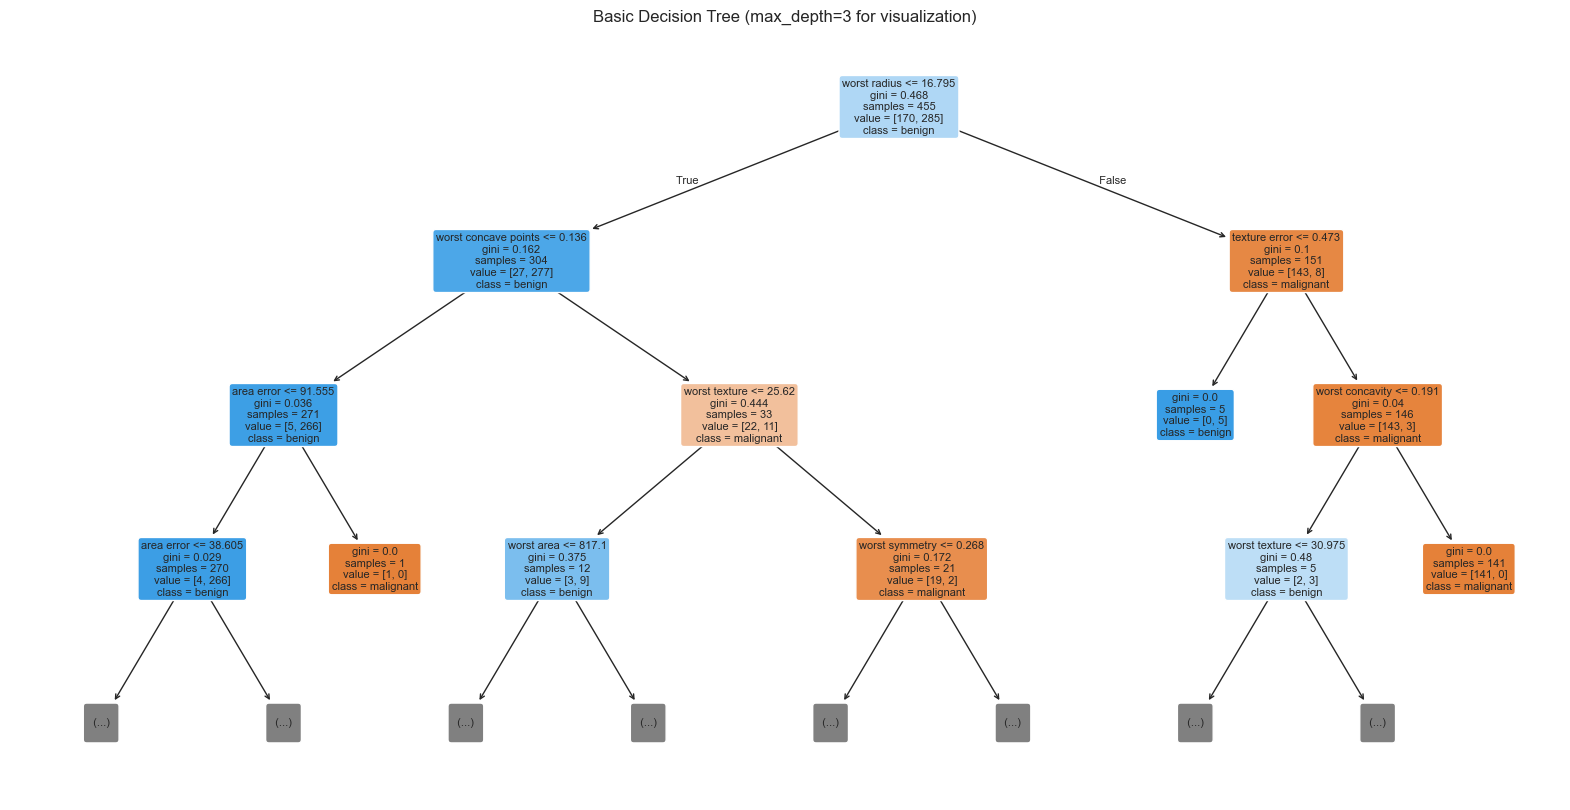

In [6]:
# Let's visualize the basic tree (limiting depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(dt_basic, 
          feature_names=cancer.feature_names,  
          class_names=cancer.target_names,
          filled=True, 
          rounded=True, 
          fontsize=8,
          max_depth=3) # Only show first 3 levels
plt.title('Basic Decision Tree (max_depth=3 for visualization)')
plt.show()

In [7]:
# Example: Decision Tree with max_depth=5
dt_max__depth = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_max__depth.fit(X_train, y_train)

y_predict_md = dt_max__depth.predict(X_test)
print(f"\nClassification Report MD: {classification_report(y_test, y_predict_md, target_names=cancer.target_names)}")

# Example: Decision Tree with min_samples_leaf=10
dt_min_samples_leaf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
dt_min_samples_leaf.fit(X_train, y_train)

y_predict_ms = dt_min_samples_leaf.predict(X_test)

print(f"\nClassification Report MS: {classification_report(y_test, y_predict_ms, target_names=cancer.target_names)}")

# You can try other combinations and see how they affect accuracy!


Classification Report MD:               precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


Classification Report MS:               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### 2.3 Exercise: Tune a Decision Tree

Try to find a combination of `max_depth`, `min_samples_split`, and `min_samples_leaf` that gives a good balance between training and testing accuracy. You can use `GridSearchCV` to help you!

In [11]:
# Exercise: Implement GridSearchCV for Decision Tree
# Define a parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create a GridSearchCV object
gscv = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=param_grid_dt)

# Fit the grid search to the training data
gscv.fit(X_train, y_train)
best_dt_model = gscv.best_estimator_

# Evaluate the best model on the test set
y_predict_gscv = best_dt_model.predict(X_test)

print(f"{accuracy_score(y_test, y_predict_gscv)}")

0.9210526315789473


## 3. Random Forests for Classification

Random Forests are an ensemble method that builds multiple decision trees and combines their predictions. This often leads to better performance and less overfitting than a single decision tree.

### 3.1 Basic Random Forest

Let's train a `RandomForestClassifier` with default settings.

In [13]:
# Initialize a basic Random Forest Classifier
rf_basic = RandomForestClassifier(random_state=42)

# Train the model
rf_basic.fit(X_train, y_train)

# Make predictions on the test set
y_predict_rfc = rf_basic.predict(X_test)

# Evaluate the model

print(f"\nClassification Report:{classification_report(y_test, y_predict_rfc, target_names=cancer.target_names)}")



Classification Report:              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 3.2 Exploring Key Parameters of Random Forests

Random Forests have several important parameters:

- `n_estimators`: The number of trees in the forest. More trees generally lead to better performance but take longer to train.
- `max_depth`: The maximum depth of each tree in the forest. Similar to Decision Trees, it controls individual tree complexity.
- `max_features`: The number of features to consider when looking for the best split. Can be an integer, float, or `"sqrt"` (square root of total features) or `"log2"` (log base 2 of total features). This introduces randomness and reduces correlation between trees.
- `oob_score`: Whether to use out-of-bag samples to estimate the generalization accuracy. OOB samples are those not used in the bootstrap sample for a given tree.

In [ ]:
# Example: Random Forest with fewer estimators
rf_fe = RandomForestClassifier(n_estimators=10)



# Example: Random Forest with max_features='log2'
rf_mf = RandomForestClassifier(max_features='log2')

# Check OOB Score (if enabled)


### 3.3 Feature Importance with Random Forests

Random Forests can also tell us which features were most important for making predictions.

In [ ]:
# Get feature importances
feature_importances = rf_basic.feature_importances_
features_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### 3.4 Exercise: Tune a Random Forest

Experiment with `n_estimators`, `max_depth`, and `max_features` to see how they affect the model's performance. Can you beat the default Random Forest accuracy?

In [14]:
# Exercise: Implement GridSearchCV for Random Forest
# Define a parameter grid
param_grid_rf_ex = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}

# Create a GridSearchCV object
gscv = GridSearchCV(RandomForestClassifier(random_state=42), 
                    param_grid=param_grid_rf_ex, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
gscv.fit(X_train, y_train)

# Evaluate the best model on the test set
print(f"{gscv.best_estimator_}")


RandomForestClassifier(max_depth=5, n_estimators=150, random_state=42)


## 4. Boosting Methods for Classification

Boosting is another powerful ensemble technique where models are built sequentially. Each new model tries to correct the errors made by the previous ones. We'll look at three popular boosting algorithms: AdaBoost, Gradient Boosting, and XGBoost.

In [ ]:
# 4.1 AdaBoost Classifier
ada_clf = AdaBoostClassifier()

ada_clf.fit(X_train, y_train)

### 4.1 AdaBoost (Adaptive Boosting)

AdaBoost combines multiple "weak" learners (often shallow decision trees) to create a strong learner. It focuses on samples that were misclassified by previous learners.

In [16]:
# 4.2 Gradient Boosting Classifier
print("\n--- Gradient Boosting Classifier ---")
gb_clf = GradientBoostingClassifier()


--- Gradient Boosting Classifier ---


### 4.2 Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree tries to predict the "residuals" (errors) of the previous trees. It's a very powerful and flexible algorithm.

In [ ]:
# 4.3 XGBoost Classifier
print("\n--- XGBoost Classifier ---")
xgb_clf = 

### 4.3 XGBoost (Extreme Gradient Boosting)

XGBoost is an optimized and highly efficient implementation of gradient boosting. It's known for its speed and performance, especially in competitive machine learning.

In [ ]:
# Exercise: Experiment with Boosting Parameters
# 